In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import pickle as pk
import os, sys

from sklearn.metrics import roc_auc_score
sys.path.append(os.path.abspath(os.path.join(os.path.dirname("./"), os.pardir)))

In [2]:
# training set to trace the training ids
y = pd.read_csv("data/training_test_set_unified.txt", sep="\t", index_col="Mithril_id").label\
    .replace(["benign", "likely benign", "likely pathogenic", "pathogenic"], [0, 0, 1, 1])
X = pd.read_csv("checkpoints/mithril_features.csv", sep="\t", index_col=0)
X = X.loc[y.index.intersection(X.index)]
y = y.loc[X.index].astype(int)
y

/tmp/ipykernel_203457/2500238834.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace(["benign", "likely benign", "likely pathogenic", "pathogenic"], [0, 0, 1, 1])


Mithril_id
MITHRIL.1942    0
MITHRIL.1948    0
MITHRIL.1955    0
MITHRIL.1958    0
MITHRIL.1960    0
               ..
MITHRIL.9638    0
MITHRIL.9650    0
MITHRIL.9659    0
MITHRIL.9662    0
MITHRIL.9678    0
Name: label, Length: 1078, dtype: int64

In [3]:
y_clingen = pd.read_csv("data/test_set.txt", sep="\t", index_col="Mithril_id").label\
    .replace(["Benign", "Likely benign", "Likely Pathogenic", "Pathogenic"], [0, 0, 1, 1])
y_clingen

/tmp/ipykernel_203457/1050219145.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace(["Benign", "Likely benign", "Likely Pathogenic", "Pathogenic"], [0, 0, 1, 1])


Mithril_id
MITHRIL.2038    0
MITHRIL.2124    0
MITHRIL.2128    0
MITHRIL.2154    0
MITHRIL.2248    0
MITHRIL.2304    0
MITHRIL.2472    0
MITHRIL.2787    0
MITHRIL.2850    0
MITHRIL.2938    0
MITHRIL.3051    0
MITHRIL.3118    0
MITHRIL.3121    0
MITHRIL.3143    0
MITHRIL.3319    0
MITHRIL.3565    0
MITHRIL.3727    0
MITHRIL.4312    0
MITHRIL.4323    0
MITHRIL.4418    0
MITHRIL.4481    1
MITHRIL.4663    1
MITHRIL.4791    0
MITHRIL.5098    0
MITHRIL.5117    0
MITHRIL.5154    0
MITHRIL.5162    0
MITHRIL.5206    0
MITHRIL.5212    0
MITHRIL.5431    0
MITHRIL.5464    0
MITHRIL.5548    0
MITHRIL.5661    0
MITHRIL.5999    0
MITHRIL.6275    0
MITHRIL.6733    0
MITHRIL.6776    0
MITHRIL.6995    0
MITHRIL.7072    0
MITHRIL.7246    0
MITHRIL.7324    0
MITHRIL.7741    0
MITHRIL.8116    0
MITHRIL.8271    0
MITHRIL.8302    0
MITHRIL.8366    0
MITHRIL.8548    0
MITHRIL.8653    0
MITHRIL.9079    0
MITHRIL.9590    0
MITHRIL.9598    0
Name: label, dtype: int64

In [4]:
mithril_features = pd.read_csv("checkpoints/mithril_features.csv", sep="\t", index_col="Mithril_id")
mithril_features

,PhastCons_100V,PhyloP_100V,MLC_score,closest_modification,closest_modification_2D,ref_frequency,alt_frequency,coverage,entropy,conservation_blocks,PWM_score,ddG,x_coord,y_coord,z_coord
Mithril_id,,,,,,,,,,,,,,,
MITHRIL.1941,0.016,-1.211,0.519343,428,68.0,0.063046,0.734159,0.414031,1.007675,5.0,1.554394,0.0,74.989870,3.792304,-17.815130
MITHRIL.1942,0.016,-1.211,0.519343,428,68.0,0.063046,0.027632,0.414031,1.007675,5.0,-3.177276,0.0,74.989870,3.792304,-17.815130
MITHRIL.1943,0.016,-1.211,0.519343,428,68.0,0.063046,0.175004,0.414031,1.007675,5.0,-0.514311,0.0,74.989870,3.792304,-17.815130
MITHRIL.1944,0.984,8.630,0.536906,427,67.0,0.943580,0.005642,0.431192,0.690667,5.0,-5.469367,0.0,78.754455,2.011318,-16.298545
MITHRIL.1945,0.984,8.630,0.536906,427,67.0,0.943580,0.020433,0.431192,0.690667,5.0,-3.612731,0.0,78.754455,2.011318,-16.298545
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.9683,0.000,-1.952,0.681815,160,63.0,0.331219,0.227366,0.414689,1.237161,4.0,-0.136909,0.0,-39.321650,77.760650,-31.156100
MITHRIL.9684,0.000,-1.952,0.681815,160,63.0,0.331219,0.035675,0.414689,1.237161,4.0,-2.808957,-0.2,-39.321650,77.760650,-31.156100
MITHRIL.9685,0.000,-0.833,0.709337,161,64.0,0.643931,0.186358,0.284371,0.908297,3.0,-0.423848,0.0,-31.769100,74.606700,-33.021850


In [5]:
embedding = pd.read_csv("data/Mithril_embedding_variants_256windows.csv", sep="\t", index_col=0)
embedding.index.name="Mithril_id"
embedding.columns = "channel_"+embedding.columns
embedding

,channel_0,channel_1,channel_2,channel_3,channel_4,channel_5,channel_6,channel_7,channel_8,channel_9,...,channel_758,channel_759,channel_760,channel_761,channel_762,channel_763,channel_764,channel_765,channel_766,channel_767
Mithril_id,,,,,,,,,,,,,,,,,,,,,
MITHRIL.1941,0.303513,1.383160,0.638585,-0.056332,0.176263,-0.143039,-0.985142,-0.073643,0.336082,-0.599478,...,-0.664787,0.342638,-0.699671,0.348487,0.340148,-0.661547,-0.597864,-0.348987,0.034101,-0.789595
MITHRIL.1942,0.550209,1.220003,0.230237,-0.072172,0.307337,-0.080652,-1.192470,0.338680,0.417476,-0.599843,...,-0.795870,0.374328,-0.212471,0.258718,0.568081,-0.767436,-0.461378,0.112244,-0.375101,-0.613042
MITHRIL.1943,0.459543,1.446819,0.370377,-0.316391,0.367811,0.119868,-0.938122,0.148861,0.658042,-0.837851,...,-0.601526,0.258426,-0.295742,0.531571,0.098219,-0.288436,-0.316600,-0.029138,-0.262222,-0.427665
MITHRIL.1944,0.118863,1.211255,0.680541,0.772733,0.030618,-0.126848,-0.616585,0.319752,0.465699,-0.481459,...,-0.197357,0.359017,-0.049334,-0.141238,-0.017622,0.085889,-0.126867,0.402710,0.525452,0.224361
MITHRIL.1945,0.174472,1.160523,0.451300,0.105366,0.336155,-0.178989,-0.596600,0.255072,0.611938,-0.435275,...,-0.372028,0.596866,0.099172,0.075484,-0.035451,-0.114921,-0.501647,0.671988,0.081063,-0.250176
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.9683,0.718890,0.957562,0.375530,1.028451,0.426534,-0.871481,-0.440027,-0.612123,-0.065064,-0.365776,...,0.180092,0.376471,-0.410671,-0.552921,0.194272,-0.247190,-0.207616,-0.102479,0.734206,-0.471182
MITHRIL.9684,0.859912,0.645613,-0.226261,0.669992,0.278951,-0.784824,-0.595451,-0.105677,-0.029068,-0.408974,...,-0.045239,0.154268,0.257173,-0.739464,0.196565,-0.440911,-0.431372,0.007138,0.411753,-0.449467
MITHRIL.9685,0.567578,0.794154,0.440818,0.410750,0.398513,-0.607294,-0.894730,-0.127402,0.098248,-0.188302,...,0.814643,-0.055371,0.330179,-0.671677,0.158416,-0.441889,-0.294790,-0.144047,0.570522,-0.642164


In [6]:
rapogee = pk.load(open("checkpoints/candidate_models/model_rf.pk", "rb"))
rapogee

Pipeline(steps=[('input_selection',
                 ColumnTransformerDF(transformers=[('feature_selection',
                                                    SelectFromModelDF(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                                                                       random_state=777),
                                                                      threshold=0.01),
                                                    Index(['PhastCons_100V', 'PhyloP_100V', 'MLC_score', 'closest_modification',
       'closest_modification_2D', 'ref_frequency', 'alt_frequency', 'coverage',
       'entropy'...
                 GridSearchOOB_BinaryClassifier(estimator=BalancedRandomForestClassifier(bootstrap=True,
                                                                                         criterion='entropy',
                                                                                         max_depth=9,
                                                                                         max_features=0.1,
                                                                                         n_estimators=4096,
                                                                                         n_jobs=-1,
                                                                                         oob_score=True,
                                                                                         sampling_strategy={0: 22,
                                                                                                            1: 22}),
                                                n_jobs=16,
                                                param_grid=<sklearn.model_selection._search.ParameterGrid object at 0x7507c2ac56a0>,
                                                scoring_function=<function roc_auc_score at 0x7507c465a7a0>,
                                                verbose=99))])

In [7]:
rapogee_predictions = pd.Series(rapogee.predict_proba(mithril_features.join(embedding))[:,1], index=mithril_features.index, name="rAPOGEE_score").to_frame()
rapogee_predictions["rAPOGEE_quantile"] = pd.qcut(
    rapogee_predictions.rAPOGEE_score,
    np.linspace(0,1,51),
    labels=np.linspace(0,1,51)[:-1]
)
rapogee_predictions

,rAPOGEE_score,rAPOGEE_quantile
Mithril_id,,
MITHRIL.1941,0.262367,0.18
MITHRIL.1942,0.213403,0.10
MITHRIL.1943,0.239221,0.14
MITHRIL.1944,0.343674,0.36
MITHRIL.1945,0.351951,0.38
...,...,...
MITHRIL.9683,0.266290,0.18
MITHRIL.9684,0.302205,0.26
MITHRIL.9685,0.455647,0.60


In [8]:
rapogee_predictions["rAPOGEE_oob"] = rapogee_predictions["rAPOGEE_score"]
rapogee_predictions.loc[X.index, "rAPOGEE_oob"] = rapogee[-1].oob_decision_function_[:,1]
rapogee_predictions

,rAPOGEE_score,rAPOGEE_quantile,rAPOGEE_oob
Mithril_id,,,
MITHRIL.1941,0.262367,0.18,0.262367
MITHRIL.1942,0.213403,0.10,0.212121
MITHRIL.1943,0.239221,0.14,0.239221
MITHRIL.1944,0.343674,0.36,0.343674
MITHRIL.1945,0.351951,0.38,0.351951
...,...,...,...
MITHRIL.9683,0.266290,0.18,0.266290
MITHRIL.9684,0.302205,0.26,0.302205
MITHRIL.9685,0.455647,0.60,0.455647


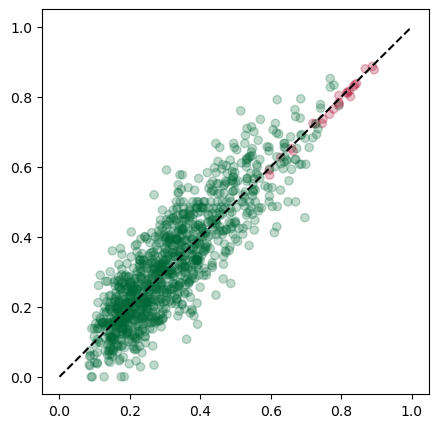

In [9]:
plt.figure(figsize=(5,5))
plt.scatter(
    rapogee_predictions.rAPOGEE_score,
    rapogee_predictions.rAPOGEE_oob,
    c=y.reindex(rapogee_predictions.index),
    cmap="RdYlGn_r", alpha=.25
)
plt.plot([0,1],[0,1], c="black", linestyle="--")
plt.show()

In [10]:
roc_auc_score(
    y, rapogee_predictions.rAPOGEE_oob.reindex(y.index)
)

np.float64(0.9836337760910816)

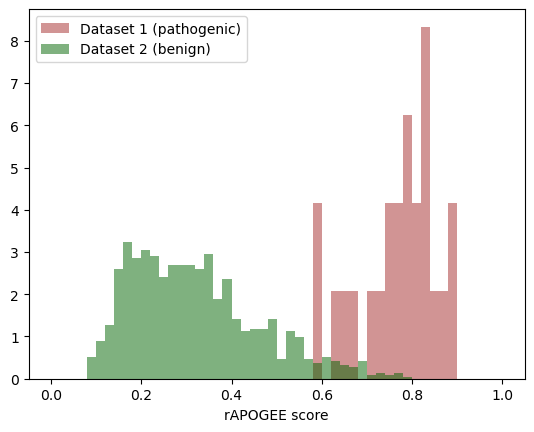

In [11]:
plt.hist(rapogee_predictions.loc[X.loc[y==1].index, "rAPOGEE_score"], bins=np.linspace(0,1,51), alpha=0.5, density=True, color="brown", label="Dataset 1 (pathogenic)")
plt.hist(rapogee_predictions.loc[X.loc[y==0].index, "rAPOGEE_score"], bins=np.linspace(0,1,51), alpha=0.5, density=True, color="darkgreen", label="Dataset 2 (benign)")


plt.xlabel("rAPOGEE score")
plt.legend()
plt.show()

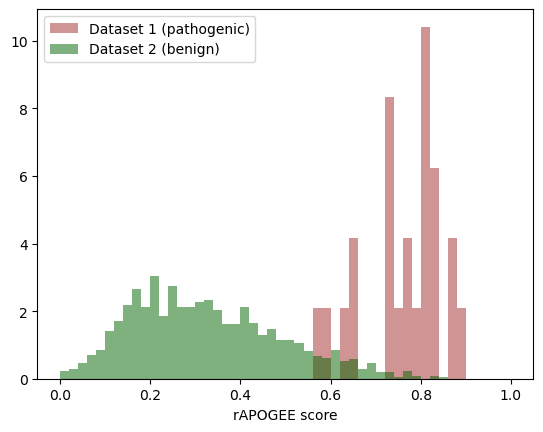

In [12]:
plt.hist(rapogee_predictions.loc[X.loc[y==1].index, "rAPOGEE_oob"], bins=np.linspace(0,1,51), alpha=0.5, density=True, color="brown", label="Dataset 1 (pathogenic)")
plt.hist(rapogee_predictions.loc[X.loc[y==0].index, "rAPOGEE_oob"], bins=np.linspace(0,1,51), alpha=0.5, density=True, color="darkgreen", label="Dataset 2 (benign)")


plt.xlabel("rAPOGEE score")
plt.legend()
plt.show()

In [13]:
from CustomEstimators.ZeroOneInflatedBeta import ZeroOneInflatedBeta

zoib = ZeroOneInflatedBeta()
zoib.fit(rapogee_predictions.rAPOGEE_oob)
zoib

0.00 * Bernoulli(0.00) + 1.00 * Beta(3.36, 4.70)

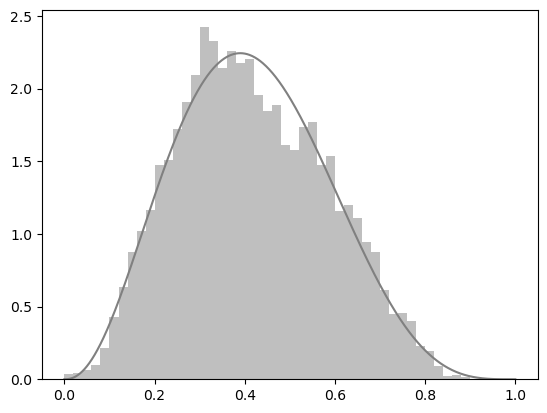

In [14]:
plt.hist(
    rapogee_predictions.rAPOGEE_oob, bins=np.linspace(0,1,51),
    alpha=0.5, density=True, color="grey"
)

zoib = ZeroOneInflatedBeta()
zoib.fit(rapogee_predictions.rAPOGEE_oob)
plt.plot(
    np.linspace(0,1,1000),
    zoib.pdf(np.linspace(0,1,1000)),
    color="grey"
)

plt.show()

/home/saldan/Desktop/projects/nAPOGEE/CustomEstimators/ZeroOneInflatedBeta.py:37: UserWarning: No extremes values have been found. Bernoulli model will not be fitted.
  warnings.warn("No extremes values have been found. Bernoulli model will not be fitted.")


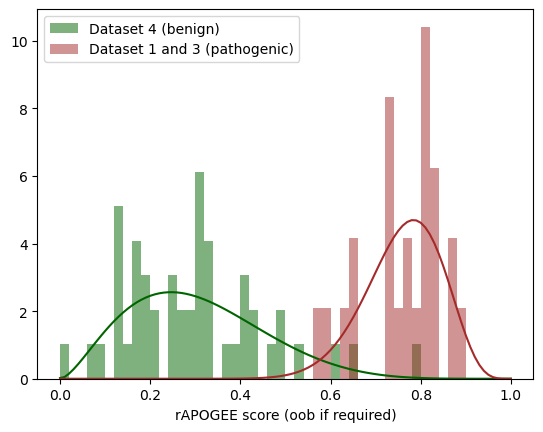

In [15]:
negative_ids = y_clingen[y_clingen==0].index
positive_ids = y[y==1].index

plt.hist(
    rapogee_predictions.loc[negative_ids, "rAPOGEE_oob"],
    bins=np.linspace(0,1,51), alpha=0.5, density=True,
    color="darkgreen", label="Dataset 4 (benign)"
)

negative_zoib = ZeroOneInflatedBeta()
negative_zoib.fit(
    rapogee_predictions.loc[negative_ids, "rAPOGEE_oob"],
)
plt.plot(
    np.linspace(0,1,101),
    negative_zoib.pdf(np.linspace(0,1,101)),
    color="darkgreen"
)

plt.hist(
    rapogee_predictions.loc[positive_ids, "rAPOGEE_oob"],
    bins=np.linspace(0,1,51), alpha=0.5, density=True,
    color="brown", label="Dataset 1 and 3 (pathogenic)"
)
positive_zoib = ZeroOneInflatedBeta()
positive_zoib.fit(
    rapogee_predictions.loc[positive_ids, "rAPOGEE_oob"],
)
plt.plot(
    np.linspace(0,1,101),
    positive_zoib.pdf(np.linspace(0,1,101)),
    color="brown"
)

plt.xlabel("rAPOGEE score (oob if required)")
plt.legend()
plt.savefig("../figures/svg/rAPOGEE_likelihood.svg")
plt.show()

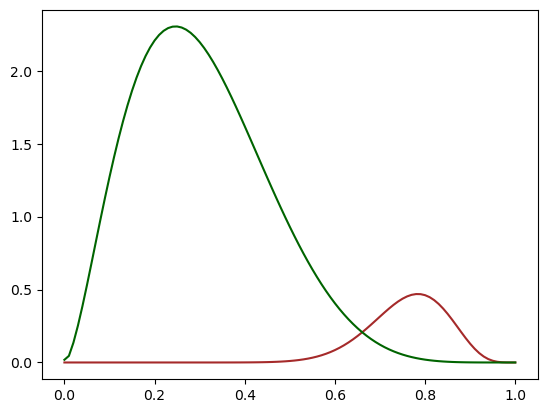

In [17]:
plt.plot(
    np.linspace(0,1,101),
    positive_zoib.pdf(np.linspace(0,1,101))*.1,
    color="brown"
)
plt.plot(
    np.linspace(0,1,101),
    negative_zoib.pdf(np.linspace(0,1,101))*.9,
    color="darkgreen"
)

/tmp/ipykernel_203457/3737202314.py:8: RuntimeWarning: invalid value encountered in divide
  posterior = (likelyhood_positive * prior) / (likelyhood_positive * prior + likelyhood_negative * (1 - prior))


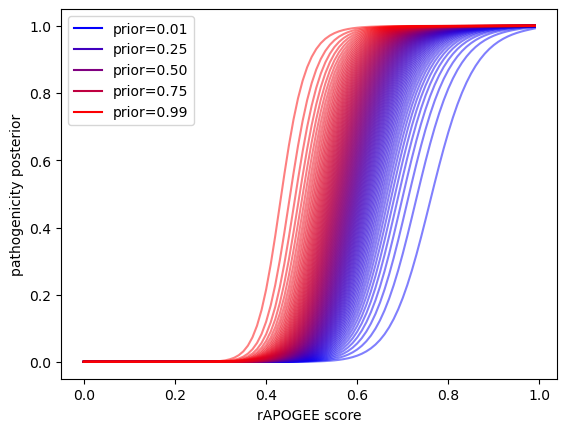

In [19]:
def posterior_proba(score, prior=0.10):
    # Positive and negative likelihoods (given the score)
    likelyhood_positive = positive_zoib.pdf(score)
    likelyhood_negative = negative_zoib.pdf(score)
    # marginal = zoib.pdf(score)
    
    # Compute the posterior probability using Bayes' theorem
    posterior = (likelyhood_positive * prior) / (likelyhood_positive * prior + likelyhood_negative * (1 - prior))
    # posterior = (likelyhood_positive * prior) / marginal
    return posterior

for prior in np.linspace(0.01,0.99,99):
    plt.plot(
        np.linspace(0,1,101), posterior_proba(np.linspace(0,1,101), prior),
        color=(prior, 0, 1-prior), alpha=.5
    )
    if prior in [0.01, .25, .5, .75, 0.99]:
        plt.plot([], [], color=(prior, 0, 1-prior), label=f"prior={prior:.2f}")

plt.xlabel("rAPOGEE score")
plt.ylabel("pathogenicity posterior")
plt.legend()
plt.savefig("../figures/svg/rAPOGEE_posterior.svg")
plt.show()

/tmp/ipykernel_179825/556881907.py:8: RuntimeWarning: invalid value encountered in divide
  posterior = (likelyhood_positive * prior) / (likelyhood_positive * prior + likelyhood_negative * (1 - prior))


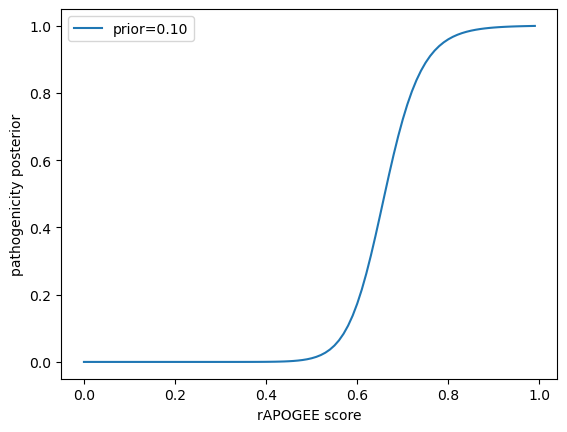

In [18]:
plt.plot(
    np.linspace(0,1,101), posterior_proba(np.linspace(0,1,101), 0.1),
    label="prior=0.10"
)
plt.xlabel("rAPOGEE score")
plt.ylabel("pathogenicity posterior")
plt.legend()
plt.show()

In [19]:
rapogee_predictions["rAPOGEE_posterior"] = posterior_proba(rapogee_predictions.rAPOGEE_oob, .1)
rapogee_predictions["category"] = pd.cut(
    rapogee_predictions.rAPOGEE_posterior, bins=[0., 0.001, 0.1, 0.9, 0.99, 1],
    labels=["benign", "likely benign", "VUS", "likely pathogenic", "pathogenic"],
    include_lowest=True
)
rapogee_predictions

,rAPOGEE_score,rAPOGEE_quantile,rAPOGEE_oob,rAPOGEE_posterior,category
Mithril_id,,,,,
MITHRIL.1941,0.262367,0.18,0.262367,3.686973e-07,benign
MITHRIL.1942,0.213403,0.10,0.212121,1.252327e-08,benign
MITHRIL.1943,0.239221,0.14,0.239221,8.477167e-08,benign
MITHRIL.1944,0.343674,0.36,0.343674,2.726607e-05,benign
MITHRIL.1945,0.351951,0.38,0.351951,3.986997e-05,benign
...,...,...,...,...,...
MITHRIL.9683,0.266290,0.18,0.266290,4.669735e-07,benign
MITHRIL.9684,0.302205,0.26,0.302205,3.505524e-06,benign
MITHRIL.9685,0.455647,0.60,0.455647,2.478844e-03,likely benign


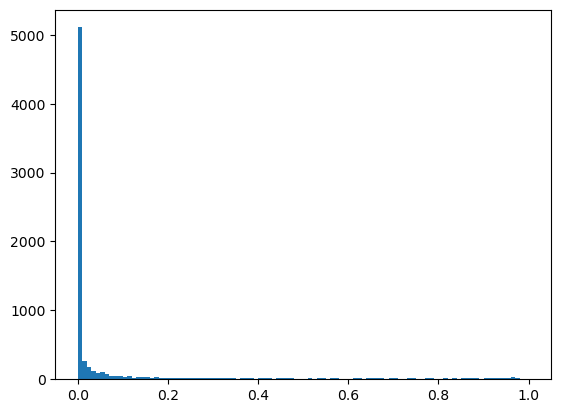

In [20]:
plt.hist(rapogee_predictions.rAPOGEE_posterior, bins=np.linspace(0,1,101))
plt.show()

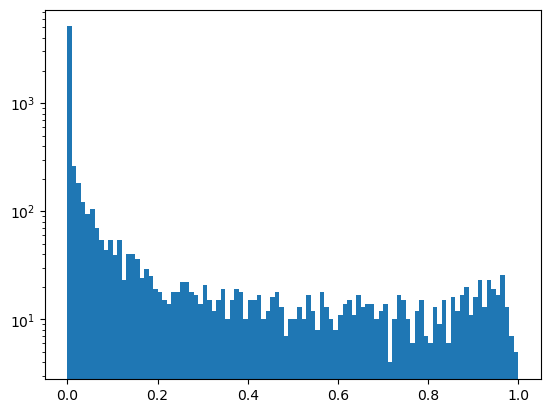

In [21]:
plt.hist(rapogee_predictions.rAPOGEE_posterior, bins=np.linspace(0,1,101))
plt.yscale("log")
plt.show()

In [22]:
rapogee_predictions.min(), rapogee_predictions.max()

(rAPOGEE_score        0.080282
 rAPOGEE_quantile          0.0
 rAPOGEE_oob               0.0
 rAPOGEE_posterior         0.0
 category               benign
 dtype: object,
 rAPOGEE_score          0.893582
 rAPOGEE_quantile           0.98
 rAPOGEE_oob            0.889431
 rAPOGEE_posterior      0.993275
 category             pathogenic
 dtype: object)

In [23]:
rapogee_predictions[rapogee_predictions.rAPOGEE_posterior>.99]

,rAPOGEE_score,rAPOGEE_quantile,rAPOGEE_oob,rAPOGEE_posterior,category
Mithril_id,,,,,
MITHRIL.4659,0.888195,0.98,0.886830,0.992917,pathogenic
MITHRIL.4728,0.889431,0.98,0.889431,0.993275,pathogenic
MITHRIL.4730,0.893582,0.98,0.877148,0.991409,pathogenic
MITHRIL.9270,0.869900,0.98,0.869900,0.990073,pathogenic
MITHRIL.9277,0.868137,0.98,0.879845,0.991858,pathogenic


In [24]:
pd.read_csv("data/mithril_V053.txt", sep="\t", low_memory=False, index_col="Mithril_id")[["Start", "Ref", "Alt", "Gene_symbol", "Gene_position"]].join(
    rapogee_predictions, how="right"
).to_csv("checkpoints/rAPOGEE_predictions.csv", sep="\t")

In [25]:
######################################################
############### MISCLASSIFICATION RATE ###############
######################################################

In [26]:
colors = plt.get_cmap("RdYlGn_r")(np.linspace(0, 1, rapogee_predictions.category.nunique()))
colors

array([[0.        , 0.40784314, 0.21568627, 1.        ],
       [0.52795079, 0.79715494, 0.40222991, 1.        ],
       [0.99992311, 0.9976163 , 0.74502115, 1.        ],
       [0.97347174, 0.54740484, 0.31810842, 1.        ],
       [0.64705882, 0.        , 0.14901961, 1.        ]])

In [ ]:
freq_matrix = pd.concat([
    rapogee_predictions.loc[y[y==0].index].groupby("category", observed=False).size(),
    rapogee_predictions.loc[y[y==1].index].groupby("category", observed=False).size()
], axis=1).T
conf_matrix = freq_matrix.div(freq_matrix.sum(axis=1), axis=0)
conf_matrix

category,benign,likely benign,VUS,likely pathogenic,pathogenic
0,0.751423,0.164137,0.074953,0.009488,0.000
1,0.000000,0.041667,0.375000,0.458333,0.125


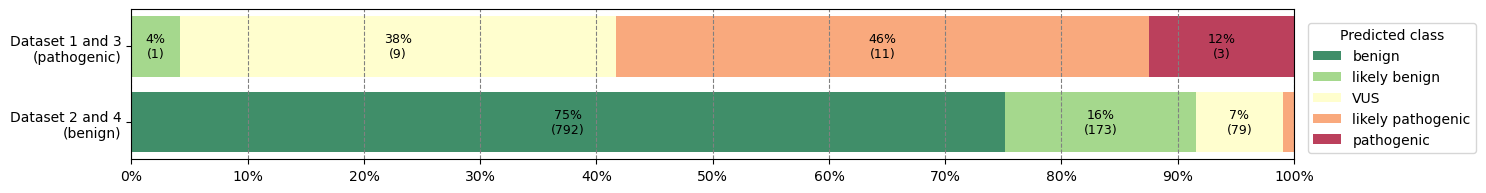

In [33]:
plt.figure(figsize=(15, 4))
plt.subplots_adjust(hspace=0.05)

plt.subplot(2,1,2)
left = np.zeros(len(conf_matrix.index))
for i, col in enumerate(conf_matrix.columns):
    plt.barh(conf_matrix.index, conf_matrix[col].values, left=left, color=colors[i], label=col, alpha=.75)
    for j, (x, y_rel, y_abs) in enumerate(zip(left, conf_matrix[col].values, freq_matrix[col].values)):
        if y_rel >= 0.03:  # only label segments wider than 3%
            plt.text(x + y_rel / 2, j, f"{y_rel*100:.0f}%\n({y_abs})", va='center', ha='center', fontsize=9, color='black')
    left += conf_matrix[col].values
plt.xticks(np.linspace(0, 1, 11), [f"{int(x)}%" for x in np.linspace(0, 1, 11)*100])
plt.yticks(conf_matrix.index, ["Dataset 2 and 4\n(benign)", "Dataset 1 and 3\n(pathogenic)"])
plt.grid(axis="x", linestyle="--", color="grey")
plt.xlim(0,1)

plt.legend(
    bbox_to_anchor=(1, 1),  # position to the right
    loc='upper left',
    borderaxespad=1,
    title="Predicted class"
)

plt.savefig("../figures/svg/rAPOGEE_misclassification.svg", bbox_inches="tight")
plt.show()